In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
print("✅ Libraries Imported")

✅ Libraries Imported


In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [13]:
print(f"Missing values in X_train: {np.isnan(X_train).sum()}")
print(f"Missing values in y_train: {np.isnan(y_train).sum()}")


Missing values in X_train: 0
Missing values in y_train: 0


In [9]:
X_train, X_test = X_train / 255.0, X_test / 255.0

In [37]:
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

In [39]:
print(f"✅ Data Loaded: {X_train.shape}")

✅ Data Loaded: (50000, 32, 32, 3)


In [15]:
X_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [17]:
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]


C:\Users\k18at\AppData\Local\Temp\ipykernel_10180\3810090739.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train.flatten(), palette="viridis")


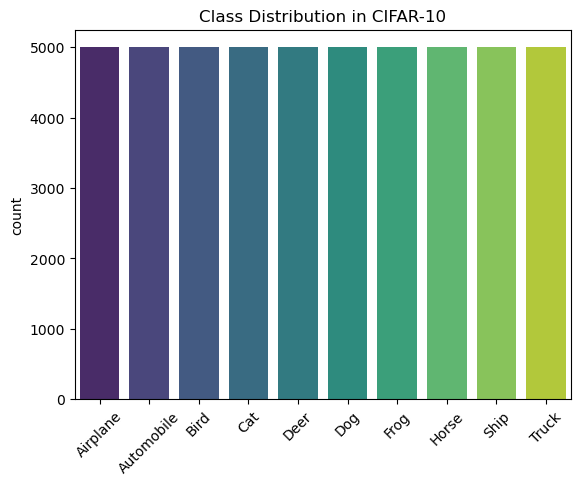

In [19]:
sns.countplot(x=y_train.flatten(), palette="viridis")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title("Class Distribution in CIFAR-10")
plt.show()

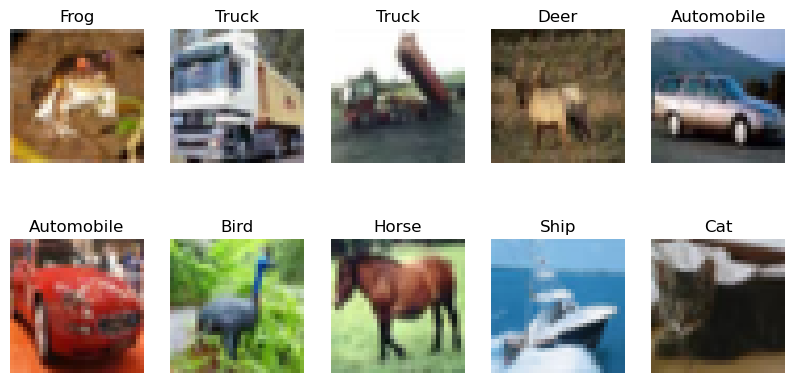

In [23]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [27]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


In [33]:
datagen.fit(X_train)

In [35]:
X_train

array([[[[0.23137255, 0.24313725, 0.24705882],
         [0.16862745, 0.18039216, 0.17647059],
         [0.19607843, 0.18823529, 0.16862745],
         ...,
         [0.61960784, 0.51764706, 0.42352941],
         [0.59607843, 0.49019608, 0.4       ],
         [0.58039216, 0.48627451, 0.40392157]],

        [[0.0627451 , 0.07843137, 0.07843137],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509804, 0.21568627],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117647, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215686, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941176, 0.19607843],
         [0.47058824, 0.32941176, 0.19607843],
         [0.42745098, 0.28627451, 0.16470588]],

        ...,

        [[0.81568627, 0.66666667, 0.37647059],
         [0.78823529, 0.6       , 0.13333333]

In [41]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

C:\Users\k18at\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("✅ CNN Model Defined")

✅ CNN Model Defined


In [45]:
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test), batch_size=64)
print("✅ Model Trained")

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.2970 - loss: 1.8875 - val_accuracy: 0.5153 - val_loss: 1.3289
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.5110 - loss: 1.3707 - val_accuracy: 0.5989 - val_loss: 1.1395
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5944 - loss: 1.1493 - val_accuracy: 0.6367 - val_loss: 1.0382
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.6354 - loss: 1.0419 - val_accuracy: 0.6737 - val_loss: 0.9261
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6687 - loss: 0.9430 - val_accuracy: 0.6881 - val_loss: 0.8934
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6976 - loss: 0.8707 - val_accuracy: 0.6659 - val_loss: 0.9376
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.7158 - loss: 0.8131 - val_accuracy: 0.7055 - val_loss: 0.8556
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.7358 - loss: 0.7599 - 

In [47]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7252 - loss: 0.8593
Test Accuracy: 0.7212


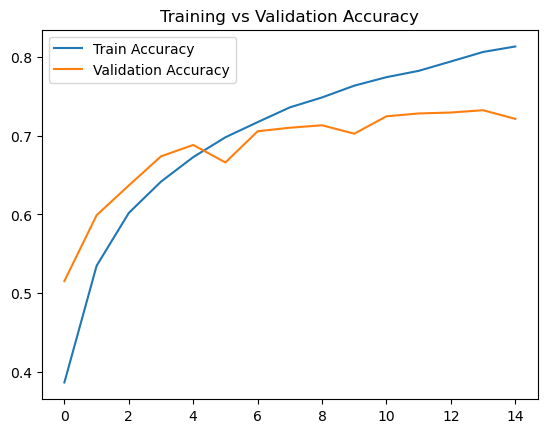

✅ Evaluation Complete


In [49]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

print("✅ Evaluation Complete")